In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

best_model = joblib.load("../models/best_match_prediction_model.pkl")

features = joblib.load("../models/model_features.pkl")

matches = pd.read_csv("../data/processed/matches_with_advanced_features.csv")

matches["date"] = pd.to_datetime(matches["date"])

features

['elo_difference',
 'home_advantage',
 'recent_win_rate_difference',
 'recent_goals_for_difference',
 'recent_goals_against_difference',
 'recent_goal_difference_difference',
 'rest_days_difference',
 'streak_difference',
 'is_world_cup',
 'is_qualification',
 'is_friendly',
 'tournament_importance',
 'head_to_head_difference',
 'attack_rating_difference',
 'defense_rating_difference']

In [2]:
current_round_of_16 = {
    "qf_1_left": {
        "team_1": "Morocco",
        "team_2": "France",
        "already_decided": True,
        "winner": None,
    },
    "qf_2_left": {
        "team_1": "Portugal",
        "team_2": "Spain",
        "already_decided": False,
        "winner": None,
    },
    "qf_2_right": {
        "team_1": "United States",
        "team_2": "Belgium",
        "already_decided": False,
        "winner": None,
    },
    "qf_3_left": {
        "team_1": "Brazil",
        "team_2": "Norway",
        "already_decided": False,
        "winner": None,
    },
    "qf_3_right": {
        "team_1": "Mexico",
        "team_2": "England",
        "already_decided": False,
        "winner": None,
    },
    "qf_4_left": {
        "team_1": "Argentina",
        "team_2": "Egypt",
        "already_decided": False,
        "winner": None,
    },
    "qf_4_right": {
        "team_1": "Switzerland",
        "team_2": "Colombia",
        "already_decided": False,
        "winner": None,
    },
}

In [3]:
def get_latest_team_row(team):
    team_matches = matches[
        (matches["home_team"] == team) |
        (matches["away_team"] == team)
    ].sort_values("date")

    if len(team_matches) == 0:
        return None

    return team_matches.iloc[-1]


def get_latest_team_profile(team):
    row = get_latest_team_row(team)

    if row is None:
        return {
            "elo": 1500,
            "attack": 1.0,
            "defense": 1.0,
            "streak": 0,
            "last_match_date": pd.Timestamp("2026-06-01"),
        }

    if row["home_team"] == team:
        elo = row.get("home_elo_before", 1500)
        attack = row.get("home_attack_before", 1.0)
        defense = row.get("home_defense_before", 1.0)
        streak = row.get("home_streak", 0)
    else:
        elo = row.get("away_elo_before", 1500)
        attack = row.get("away_attack_before", 1.0)
        defense = row.get("away_defense_before", 1.0)
        streak = row.get("away_streak", 0)

    return {
        "elo": elo,
        "attack": attack,
        "defense": defense,
        "streak": streak,
        "last_match_date": row["date"],
    }

In [4]:
def get_recent_form_for_team(team, n_matches=5):
    team_matches = matches[
        (matches["home_team"] == team) |
        (matches["away_team"] == team)
    ].sort_values("date").tail(n_matches)

    if len(team_matches) == 0:
        return {
            "win_rate": 0,
            "goals_for": 0,
            "goals_against": 0,
            "goal_difference": 0,
        }

    wins = 0
    goals_for = 0
    goals_against = 0

    for _, match in team_matches.iterrows():
        if match["home_team"] == team:
            team_goals = match["home_score"]
            opponent_goals = match["away_score"]
        else:
            team_goals = match["away_score"]
            opponent_goals = match["home_score"]

        goals_for += team_goals
        goals_against += opponent_goals

        if team_goals > opponent_goals:
            wins += 1

    games = len(team_matches)

    return {
        "win_rate": wins / games,
        "goals_for": goals_for / games,
        "goals_against": goals_against / games,
        "goal_difference": (goals_for - goals_against) / games,
    }

In [6]:
def get_head_to_head_difference(home_team, away_team):
    previous_matches = matches[
        (
            ((matches["home_team"] == home_team) & (matches["away_team"] == away_team)) |
            ((matches["home_team"] == away_team) & (matches["away_team"] == home_team))
        )
    ]

    home_wins = 0
    away_wins = 0

    for _, match in previous_matches.iterrows():
        if match["home_score"] > match["away_score"]:
            winner = match["home_team"]
        elif match["home_score"] < match["away_score"]:
            winner = match["away_team"]
        else:
            winner = None

        if winner == home_team:
            home_wins += 1
        elif winner == away_team:
            away_wins += 1

    return home_wins - away_wins

In [17]:
def build_live_match_features(home_team, away_team, match_date, neutral=True):
    home_profile = get_latest_team_profile(home_team)
    away_profile = get_latest_team_profile(away_team)

    home_form = get_recent_form_for_team(home_team)
    away_form = get_recent_form_for_team(away_team)

    home_rest_days = (match_date - home_profile["last_match_date"]).days
    away_rest_days = (match_date - away_profile["last_match_date"]).days

    row = {
        "elo_difference": home_profile["elo"] - away_profile["elo"],
        "home_advantage": 0 if neutral else 1,

        "recent_win_rate_difference": (
            home_form["win_rate"] - away_form["win_rate"]
        ),

        "recent_goals_for_difference": (
            home_form["goals_for"] - away_form["goals_for"]
        ),

        "recent_goals_against_difference": (
            home_form["goals_against"] - away_form["goals_against"]
        ),

        "recent_goal_difference_difference": (
            home_form["goal_difference"] - away_form["goal_difference"]
        ),

        "rest_days_difference": home_rest_days - away_rest_days,

        "streak_difference": (
            home_profile["streak"] - away_profile["streak"]
        ),

        "is_world_cup": 1,
        "is_qualification": 0,
        "is_friendly": 0,
        "tournament_importance": 4,

        "head_to_head_difference": get_head_to_head_difference(
            home_team,
            away_team
        ),

        "attack_rating_difference": (
            home_profile["attack"] - away_profile["attack"]
        ),

        "defense_rating_difference": (
            home_profile["defense"] - away_profile["defense"]
        ),
    }

    X_live = pd.DataFrame([row])[features]

    X_live = X_live.fillna({
        "elo_difference": 0,
        "home_advantage": 0,
        "recent_win_rate_difference": 0,
        "recent_goals_for_difference": 0,
        "recent_goals_against_difference": 0,
        "recent_goal_difference_difference": 0,
        "rest_days_difference": 0,
        "streak_difference": 0,
        "is_world_cup": 1,
        "is_qualification": 0,
        "is_friendly": 0,
        "tournament_importance": 4,
        "head_to_head_difference": 0,
        "attack_rating_difference": 0,
        "defense_rating_difference": 0,
    })

    return X_live
X_test_live = build_live_match_features(
    "Brazil",
    "Norway",
    pd.Timestamp("2026-07-05")
)

X_test_live

,elo_difference,home_advantage,recent_win_rate_difference,recent_goals_for_difference,recent_goals_against_difference,recent_goal_difference_difference,rest_days_difference,streak_difference,is_world_cup,is_qualification,is_friendly,tournament_importance,head_to_head_difference,attack_rating_difference,defense_rating_difference
0,117.744615,0,0.0,0.0,0.0,0.0,0,2,1,0,0,4,-2,0.37906,1.225396


In [18]:
def predict_live_match(home_team, away_team, match_date, neutral=True):
    X_match = build_live_match_features(
        home_team,
        away_team,
        match_date,
        neutral
    )

    probabilities = best_model.predict_proba(X_match)[0]

    return dict(zip(best_model.classes_, probabilities))

In [19]:
predict_live_match(
    "Brazil",
    "Norway",
    pd.Timestamp("2026-07-05")
)

{'away_win': np.float64(0.1265443021189367),
 'draw': np.float64(0.28199913057694187),
 'home_win': np.float64(0.5914565673041214)}

In [23]:
prediction_cache = {}

def simulate_live_knockout_match(home_team, away_team, match_date):
    cache_key = (
        home_team,
        away_team,
        pd.Timestamp(match_date),
        True
    )

    if cache_key not in prediction_cache:
        prediction_cache[cache_key] = predict_live_match(
            home_team,
            away_team,
            match_date,
            neutral=True
        )

    probabilities = prediction_cache[cache_key]

    home_prob = probabilities.get("home_win", 0)
    away_prob = probabilities.get("away_win", 0)

    total = home_prob + away_prob

    if total == 0:
        return np.random.choice([home_team, away_team])

    home_advances_prob = home_prob / total

    return np.random.choice(
        [home_team, away_team],
        p=[home_advances_prob, 1 - home_advances_prob]
    )

In [25]:
def simulate_live_world_cup_once():
    match_dates = {
        "qf_2_left": pd.Timestamp("2026-07-06"),
        "qf_2_right": pd.Timestamp("2026-07-06"),
        "qf_3_left": pd.Timestamp("2026-07-05"),
        "qf_3_right": pd.Timestamp("2026-07-05"),
        "qf_4_left": pd.Timestamp("2026-07-07"),
        "qf_4_right": pd.Timestamp("2026-07-07"),
        "quarterfinal": pd.Timestamp("2026-07-09"),
        "semifinal": pd.Timestamp("2026-07-14"),
        "final": pd.Timestamp("2026-07-19"),
    }

    qf_1_team_1 = "Morocco"
    qf_1_team_2 = "France"

    qf_2_left_winner = simulate_live_knockout_match(
        "Portugal",
        "Spain",
        match_dates["qf_2_left"]
    )

    qf_2_right_winner = simulate_live_knockout_match(
        "United States",
        "Belgium",
        match_dates["qf_2_right"]
    )

    qf_3_left_winner = simulate_live_knockout_match(
        "Brazil",
        "Norway",
        match_dates["qf_3_left"]
    )

    qf_3_right_winner = simulate_live_knockout_match(
        "Mexico",
        "England",
        match_dates["qf_3_right"]
    )

    qf_4_left_winner = simulate_live_knockout_match(
        "Argentina",
        "Egypt",
        match_dates["qf_4_left"]
    )

    qf_4_right_winner = simulate_live_knockout_match(
        "Switzerland",
        "Colombia",
        match_dates["qf_4_right"]
    )

    qf_1_winner = simulate_live_knockout_match(
        qf_1_team_1,
        qf_1_team_2,
        match_dates["quarterfinal"]
    )

    qf_2_winner = simulate_live_knockout_match(
        qf_2_left_winner,
        qf_2_right_winner,
        match_dates["quarterfinal"]
    )

    qf_3_winner = simulate_live_knockout_match(
        qf_3_left_winner,
        qf_3_right_winner,
        match_dates["quarterfinal"]
    )

    qf_4_winner = simulate_live_knockout_match(
        qf_4_left_winner,
        qf_4_right_winner,
        match_dates["quarterfinal"]
    )

    sf_1_winner = simulate_live_knockout_match(
        qf_1_winner,
        qf_2_winner,
        match_dates["semifinal"]
    )

    sf_2_winner = simulate_live_knockout_match(
        qf_3_winner,
        qf_4_winner,
        match_dates["semifinal"]
    )

    champion = simulate_live_knockout_match(
        sf_1_winner,
        sf_2_winner,
        match_dates["final"]
    )

    return {
        "round_of_16_winners": [
            "Morocco",
            "France",
            qf_2_left_winner,
            qf_2_right_winner,
            qf_3_left_winner,
            qf_3_right_winner,
            qf_4_left_winner,
            qf_4_right_winner,
        ],
        "quarterfinalists": [
            "Morocco",
            "France",
            qf_2_left_winner,
            qf_2_right_winner,
            qf_3_left_winner,
            qf_3_right_winner,
            qf_4_left_winner,
            qf_4_right_winner,
        ],
        "semifinalists": [
            qf_1_winner,
            qf_2_winner,
            qf_3_winner,
            qf_4_winner,
        ],
        "finalists": [
            sf_1_winner,
            sf_2_winner,
        ],
        "champion": champion,
    }

In [26]:
teams_remaining = [
    "Morocco",
    "France",
    "Portugal",
    "Spain",
    "United States",
    "Belgium",
    "Brazil",
    "Norway",
    "Mexico",
    "England",
    "Argentina",
    "Egypt",
    "Switzerland",
    "Colombia",
]

num_simulations = 10000

live_results = {}

for team in teams_remaining:
    live_results[team] = {
        "quarterfinal": 0,
        "semifinal": 0,
        "final": 0,
        "champion": 0,
    }


for _ in range(num_simulations):
    result = simulate_live_world_cup_once()

    for team in result["quarterfinalists"]:
        live_results[team]["quarterfinal"] += 1

    for team in result["semifinalists"]:
        live_results[team]["semifinal"] += 1

    for team in result["finalists"]:
        live_results[team]["final"] += 1

    live_results[result["champion"]]["champion"] += 1


live_prediction_results = pd.DataFrame.from_dict(
    live_results,
    orient="index"
)

live_prediction_results = live_prediction_results / num_simulations

live_prediction_results = live_prediction_results.sort_values(
    "champion",
    ascending=False
)

live_prediction_results

,quarterfinal,semifinal,final,champion
Argentina,0.9046,0.7391,0.4673,0.3059
Spain,0.7024,0.5956,0.4028,0.2037
Brazil,0.8279,0.6024,0.3075,0.1814
France,1.0000,0.6940,0.3436,0.1480
England,0.7778,0.3004,0.1326,0.0669
Portugal,0.2976,0.2218,0.0989,0.0307
Morocco,1.0000,0.3060,0.1003,0.0218
Colombia,0.7353,0.1893,0.0548,0.0200
Belgium,0.7084,0.1442,0.0461,0.0121
Norway,0.1721,0.0524,0.0153,0.0030


In [ ]:
live_prediction_results.to_csv(
    "../data/processed/live_world_cup_prediction_results.csv"
)

live_prediction_results.head(10)

In [ ]:
top_champion_probs = live_prediction_results["champion"].head(10)

top_champion_probs.plot(kind="bar")

plt.title("Live World Cup Champion Probabilities")
plt.ylabel("Champion Probability")
plt.xlabel("Team")

plt.show()

In [ ]:
top_final_probs = live_prediction_results["final"].sort_values(
    ascending=False
).head(10)

top_final_probs.plot(kind="bar")

plt.title("Live World Cup Final Appearance Probabilities")
plt.ylabel("Final Probability")
plt.xlabel("Team")

plt.show()

In [27]:
live_prediction_results_percent = live_prediction_results * 100

live_prediction_results_percent.round(2)

,quarterfinal,semifinal,final,champion
Argentina,90.46,73.91,46.73,30.59
Spain,70.24,59.56,40.28,20.37
Brazil,82.79,60.24,30.75,18.14
France,100.00,69.40,34.36,14.80
England,77.78,30.04,13.26,6.69
Portugal,29.76,22.18,9.89,3.07
Morocco,100.00,30.60,10.03,2.18
Colombia,73.53,18.93,5.48,2.00
Belgium,70.84,14.42,4.61,1.21
Norway,17.21,5.24,1.53,0.30


In [28]:
live_prediction_results.to_csv(
    "../data/processed/live_world_cup_prediction_results.csv"
)

live_prediction_results.head(10)

,quarterfinal,semifinal,final,champion
Argentina,0.9046,0.7391,0.4673,0.3059
Spain,0.7024,0.5956,0.4028,0.2037
Brazil,0.8279,0.6024,0.3075,0.1814
France,1.0000,0.6940,0.3436,0.1480
England,0.7778,0.3004,0.1326,0.0669
Portugal,0.2976,0.2218,0.0989,0.0307
Morocco,1.0000,0.3060,0.1003,0.0218
Colombia,0.7353,0.1893,0.0548,0.0200
Belgium,0.7084,0.1442,0.0461,0.0121
Norway,0.1721,0.0524,0.0153,0.0030


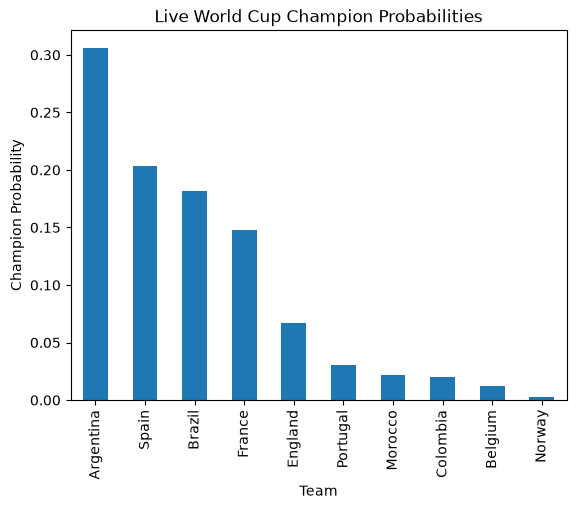

In [29]:
top_champion_probs = live_prediction_results["champion"].head(10)

top_champion_probs.plot(kind="bar")

plt.title("Live World Cup Champion Probabilities")
plt.ylabel("Champion Probability")
plt.xlabel("Team")

plt.show()

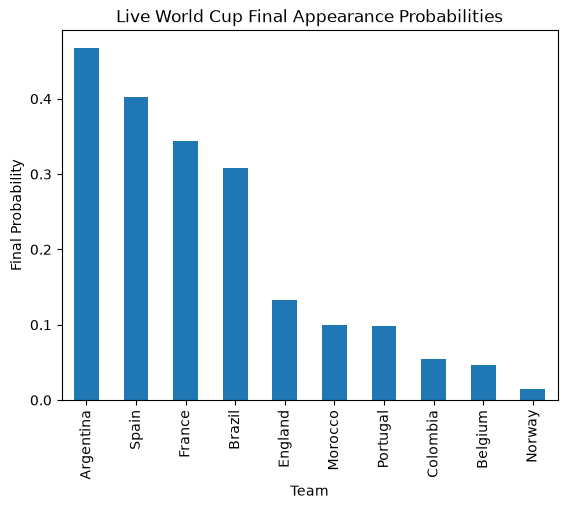

In [30]:
top_final_probs = live_prediction_results["final"].sort_values(
    ascending=False
).head(10)

top_final_probs.plot(kind="bar")

plt.title("Live World Cup Final Appearance Probabilities")
plt.ylabel("Final Probability")
plt.xlabel("Team")

plt.show()